In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import models, layers 

In [2]:
img_size = 256
batch_size = 32

In [3]:
data = tf.keras.preprocessing.image_dataset_from_directory(
    "potato_imgs",
    shuffle=True,
    image_size = (img_size, img_size),
    batch_size=batch_size 
)

Found 2151 files belonging to 3 classes.


In [4]:
classes = data.class_names
classes

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(data)

68

In [6]:
for labels, imges in data.take(1):
    print(labels.shape)
    print(imges.numpy())

(32, 256, 256, 3)
[1 0 0 1 1 1 0 0 1 2 1 1 1 1 0 0 1 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1]


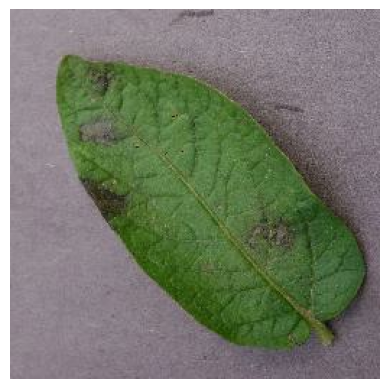

In [7]:
# for labels, imges in data.take(1):
#     print(labels[0].numpy())
import matplotlib.pyplot as plt
for labels, imges in data.take(1):
    plt.imshow(labels[0].numpy().astype("uint8"))
    plt.axis("off")

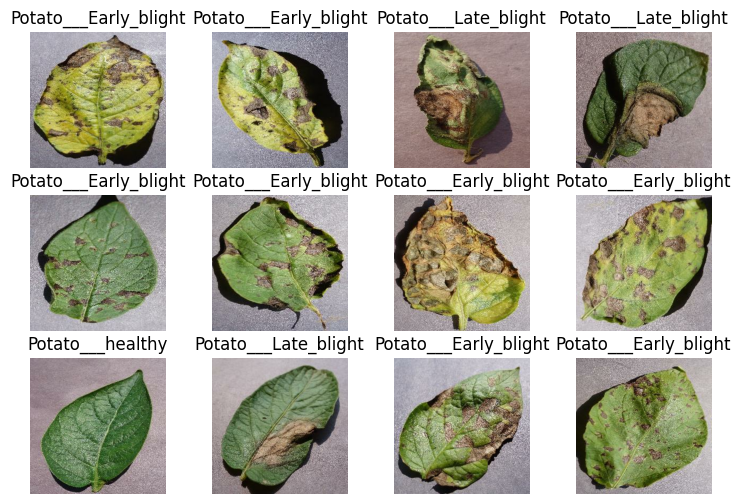

In [8]:
plt.figure(figsize=(9,6))
for labels, imges in data.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(labels[i].numpy().astype("uint8"))
        plt.title(classes[imges[i]])
        plt.axis("off")

In [9]:
train_saize = 0.8
len(data)*train_saize

54.400000000000006

In [10]:
train_data = data.take(54)
test_data = data.skip(54)

In [11]:
val_size = 0.1
len(data)*val_size

6.800000000000001

In [12]:
val_data = test_data.take(6)
len(val_data)

6

In [13]:
test_data = test_data.skip(6)
len(test_data)

8

In [14]:
def get_data_partition_tf(data, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=1000):
    ds_size = len(data)
    if shuffle:
        data = data.shuffle(shuffle_size, seed=12)
    train_size = int(ds_size*train_split)
    val_size = int(ds_size*val_split)
    
    train_ds = data.take(train_size)
    val_ds = data.skip(train_size).take(val_size)
    test_ds = data.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [15]:
train_ds, test_ds, val_ds = get_data_partition_tf(data)

In [16]:
len(train_ds)

54

In [17]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [18]:
# har img ko resize or rescale krta hai 
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(img_size, img_size),
    layers.Rescaling(1.0/255)
])


In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [100]:
channels = 3 # RGB channels means colors 
input_shape = (batch_size,img_size, img_size, channels)
n_classes = 3
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes,activation='softmax')
])
model.build(input_shape=input_shape)


C:\Users\007\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [101]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [103]:
epochs = 50
model.fit(train_ds,
          epochs=epochs,
          batch_size=batch_size,
          verbose=1,
          validation_data=val_ds
          )

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.4907 - loss: 0.9200 - val_accuracy: 0.4648 - val_loss: 0.8757
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.6620 - loss: 0.7141 - val_accuracy: 0.8086 - val_loss: 0.4374
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.8131 - loss: 0.4609 - val_accuracy: 0.8594 - val_loss: 0.3248
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.8605 - loss: 0.3336 - val_accuracy: 0.9023 - val_loss: 0.2647
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8617 - loss: 0.3348 - val_accuracy: 0.8984 - val_loss: 0.2386
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8918 - loss: 0.2633 - val_accuracy: 0.8984 - val_loss: 0.2419
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.8906 - loss: 0.2605 - val_accuracy: 0.9414 - val_loss: 0.1627
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9138 - loss: 0.2154 - val_accuracy: 0.9336 - v

In [104]:
score = model.evaluate(test_ds)

6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 378ms/step - accuracy: 0.9062 - loss: 0.3875


In [105]:
score

[0.38753077387809753, 0.90625]

label is:1
class name is : Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[9.497155e-02 9.050284e-01 5.675243e-09]
Class belog to:  Potato___Late_blight


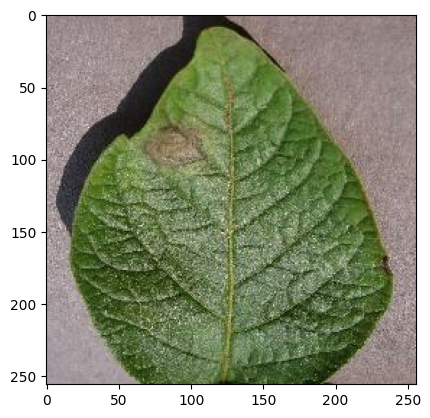

In [147]:
import numpy as np
for img_batch, label_batch in train_ds.take(1):
    first_img = img_batch[0].numpy().astype("uint8")
    first_label = label_batch[0].numpy()

    print(f"label is:{first_label}")
    print("class name is :",classes[first_label])
    plt.imshow(first_img)
    bach_prediction = model.predict(img_batch)
    print(bach_prediction[0])
    print("Class belog to: ", classes[np.argmax(bach_prediction[0])])

In [154]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # batch dimension

    prediction = model.predict(img_array)

    prediction_class = classes[np.argmax(prediction[0])]
    confidence = round(100 * np.max(prediction[0]), 2)

    return prediction_class, confidence


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


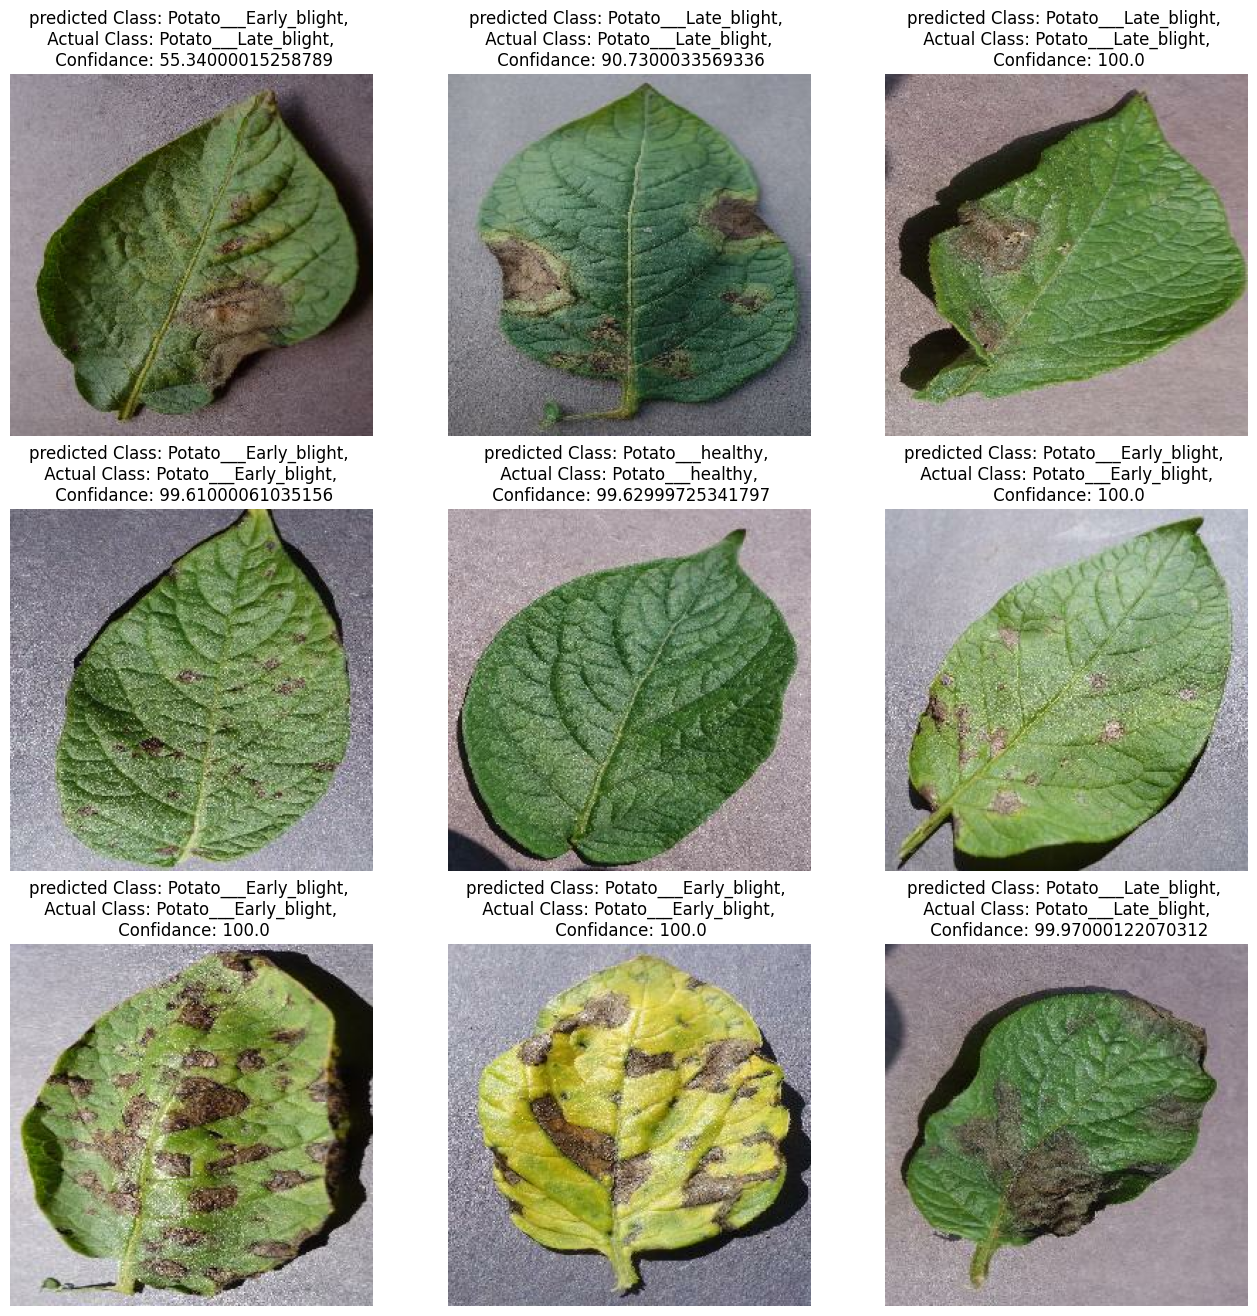

In [163]:
plt.figure(figsize=(16,16))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        predicted_class, confidance = predict(model, images[i].numpy())
        actual_class = classes[labels[i]]
        plt.title(f"predicted Class: {predicted_class}, \n Actual Class: {actual_class}, \n Confidance: {confidance}")
        plt.axis('off')

In [ ]:
model_version = 1
model.save(f"../plantsclassification/models/{model_version}.keras")